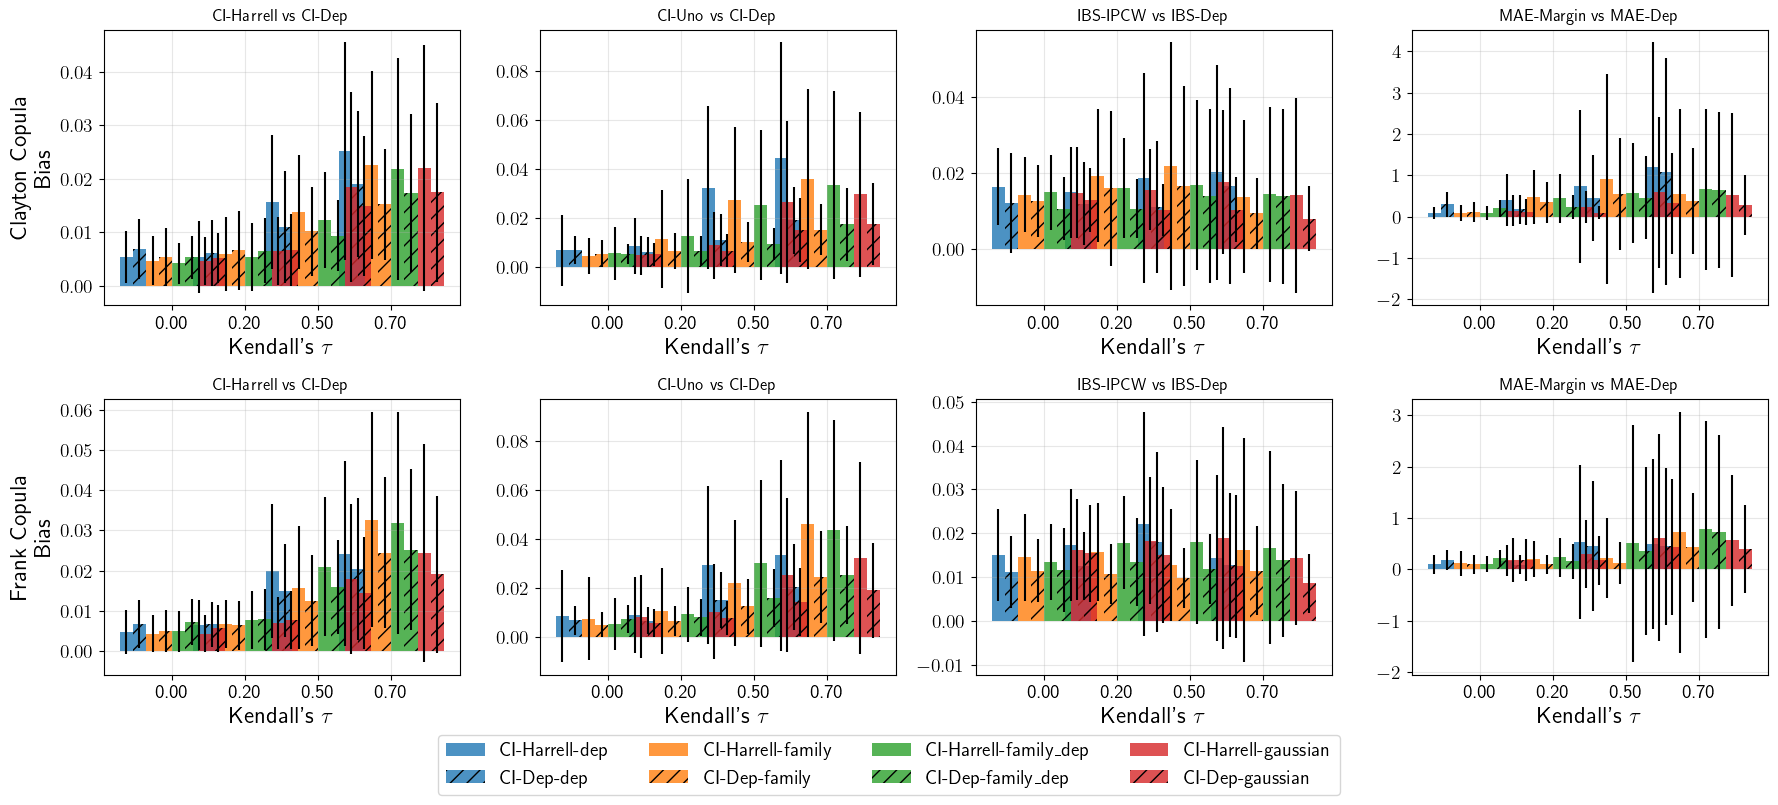

In [14]:
import numpy as np
import pandas as pd
import config as cfg
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "x-large",
    "font.size": 14.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{bm}"
})

filename = f"{cfg.RESULTS_DIR}/synthetic_results_wrong_copula.csv"
df = pd.read_csv(filename)

sigma_level = 1
z_threshold = 3

# Filter outliers
columns = [
    "ci_harrell_error", "ci_uno_error", "ci_dep_ipcw_error",
    "ibs_ipcw_error", "ibs_dep_bg_error", "mae_margin_error", "mae_dep_bg_error"
]
df = df[(np.abs((df[columns] - df[columns].mean()) / df[columns].std()) < z_threshold).all(axis=1)]

# Group
grouped = df.groupby(["experiment", "copula_name", "k_tau", "n_samples"])
mean_errors = grouped.mean().reset_index()
std_errors = grouped.std().reset_index()

# Metrics to plot
error_columns = [
    ("ci_harrell_error", "ci_dep_ipcw_error", "CI-Harrell", "CI-Dep"),
    ("ci_uno_error", "ci_dep_ipcw_error", "CI-Uno", "CI-Dep"),
    ("ibs_ipcw_error", "ibs_dep_bg_error", "IBS-IPCW", "IBS-Dep"),
    ("mae_margin_error", "mae_dep_bg_error", "MAE-Margin", "MAE-Dep")
]

copula_rows = {"clayton": 0, "frank": 1}
tau_vals = [0.0, 0.2, 0.5, 0.7]
experiments = sorted(df["experiment"].unique())  # 4 misspecifications
n_exp = len(experiments)

fig, axs = plt.subplots(2, 4, figsize=(18, 8))
bar_width = 0.18
x = np.arange(len(tau_vals))

for col_idx, (indep_metric, dep_metric, indep_name, dep_name) in enumerate(error_columns):
    for copula_name, row_idx in copula_rows.items():
        ax = axs[row_idx, col_idx]

        for i, exp in enumerate(experiments):
            copula_data = mean_errors[
                (mean_errors["copula_name"] == copula_name) &
                (mean_errors["experiment"] == exp) &
                (mean_errors["n_samples"] == 10000) &
                (mean_errors["k_tau"].isin(tau_vals))
            ].sort_values("k_tau")

            copula_std = std_errors[
                (std_errors["copula_name"] == copula_name) &
                (std_errors["experiment"] == exp) &
                (std_errors["n_samples"] == 10000) &
                (std_errors["k_tau"].isin(tau_vals))
            ].sort_values("k_tau")

            tau_vals = copula_data["k_tau"].values
            x = np.arange(len(tau_vals))

            pos = x + (i - n_exp/2) * 2*bar_width + bar_width/2

            # Baseline bars
            ax.bar(pos, copula_data[indep_metric].values, bar_width,
                   yerr=sigma_level*copula_std[indep_metric].values,
                   label=f"{indep_name}-{exp}" if row_idx == 0 and col_idx == 0 else "",
                   alpha=0.8, color=f"C{i}")

            # Dep bars
            ax.bar(pos + bar_width, copula_data[dep_metric].values, bar_width,
                   yerr=sigma_level*copula_std[dep_metric].values,
                   label=f"{dep_name}-{exp}" if row_idx == 0 and col_idx == 0 else "",
                   alpha=0.8, color=f"C{i}", hatch="//")

        # --- X-axis formatting ---
        ax.set_xticks(np.arange(len(tau_vals)))
        ax.set_xticklabels([f"{t:.2f}" for t in tau_vals])
        ax.set_xlabel("Kendall's $\\tau$")

        # --- Subplot title ---
        ax.set_title(f"{indep_name} vs {dep_name}", fontsize=12)

        # --- Y-axis ---
        if col_idx == 0:
            ax.set_ylabel(f"{copula_name.capitalize()} Copula\nBias")

        ax.grid(True, alpha=0.3)

# Legend at bottom
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"{cfg.PLOTS_DIR}/synthetic_wrong_copula.pdf", format="pdf", bbox_inches="tight")
plt.show()